Running two unbiased simulation for site A and B of alanine dipeptide

## Setup

In [28]:
from pathlib import Path
import os, subprocess
import numpy as np
import plumed
import matplotlib.pyplot as plt

In [ ]:
# Configurations
BASE_DIR   = Path("/home/dani/wslcoding/MCFM/ML-CV")
INPUT_DIR  = BASE_DIR / "input"
SAMPLE_DIR = BASE_DIR / "sample"
GMX_CMD    = "gmx_mpi"
NUM_STEPS  = 10_000   # productions: 500_000
STRIDE     = 100

os.chdir(BASE_DIR)

In [30]:
# Check working directory
os.getcwd()

'/home/dani/wslcoding/MCFM/ML-CV'

In [ ]:
# TEMPLATE PLUMED
PLUMED_TEMPLATE = f"""\
# vim:ft=plumed

# Compute torsion angles, as well as energy
MOLINFO STRUCTURE=input.ala2.pdb
phi: TORSION ATOMS=@phi-2
psi: TORSION ATOMS=@psi-2
theta: TORSION ATOMS=6,5,7,9
xi:    TORSION ATOMS=16,15,17,19
ene:   ENERGY

INCLUDE FILE={INPUT_DIR}/plumed-distances.dat

PRINT FMT=%g STRIDE={STRIDE} FILE=COLVAR ARG=*
ENDPLUMED
"""

In [ ]:
# Helper functions

def execute(command: str, folder: Path) -> None:
    result = subprocess.run(
        command, cwd=folder, shell=True,
        capture_output=True, text=True
    )
    if result.returncode == 0:
        print(f"✓ {command[:80]}")
    else:
        print(f"✗ ERROR:\n{result.stderr}")

def setup_state(label: str, tpr_src: str, clean_first: bool = False) -> Path:
    """Prepare folder for unbiased simulation
    
    label      : state identifier (es. 'sA', 'sB')
    tpr_src    : filename .tpr source in INPUT_DIR/md_inputs/
    clean_first: if true, clean previous outputs
    """
    folder = SAMPLE_DIR / f"0_unbiased-{label}"
    folder.mkdir(parents=True, exist_ok=True)

    if clean_first:
        subprocess.run(
            "rm -f bck.* COLVAR KERNELS alanine.*",
            cwd=folder, shell=True
        )

    md_in = INPUT_DIR / "md_inputs"
    execute(f"cp {md_in}/input.ala2.pdb .", folder)
    execute(f"cp {md_in}/{tpr_src} input.tpr", folder)

    (folder / "plumed.dat").write_text(PLUMED_TEMPLATE)
    return folder

def run_simulation(folder: Path, n_steps: int = NUM_STEPS) -> None:
    execute(
        f"{GMX_CMD} mdrun -s input.tpr -deffnm alanine "
        f"-plumed plumed.dat -ntomp 1 -nsteps {n_steps}",
        folder
    )

def recompute_colvar(folder: Path) -> None:
    """Ricalcola COLVAR dall'xtc con plumed driver."""
    execute("plumed driver --plumed plumed.dat --mf_xtc alanine.xtc", folder)

## 1.0 Unbiased simulations in the metastable states

First, we perform short MD simulations starting from the two snapshots of the molecule, and characterizing each state with a set of descriptors. To proceed in a blind way, we choose to use as input features all the distances between heavy atoms (the list of such descriptors are in the file `plumed-distances.dat`).

**State A**

In [35]:
folder_A = setup_state("sA", tpr_src="input.tpr", clean_first=True)

✓ cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala
✓ cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.tpr


In [36]:
run_simulation(folder_A)

✓ gmx_mpi mdrun -s input.tpr -deffnm alanine -plumed plumed.da


**State B**

In [37]:
folder_B = setup_state("sB", tpr_src="input.sB.tpr", clean_first=True)

✓ cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala
✓ cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.sB.


In [38]:
run_simulation(folder_B)

✓ gmx_mpi mdrun -s input.tpr -deffnm alanine -plumed plumed.da


### Analize simulations

Ramachandran plot of the two simulations

σ(φ) State A: 0.5246 rad
σ(φ) State B: 0.1422 rad


+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so" +++


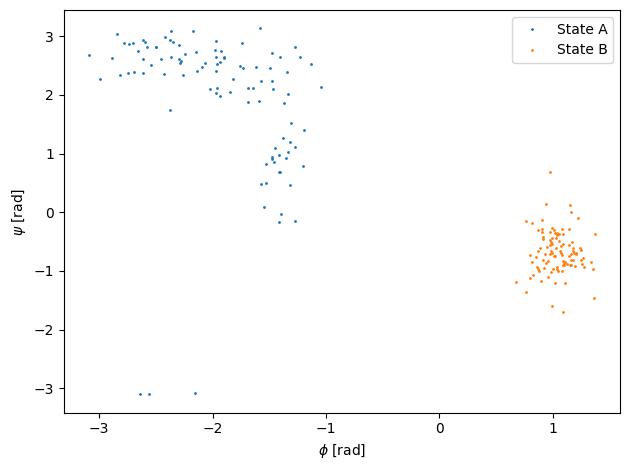

In [ ]:
# import PLUMED COLVAR files into pandas datasets
dataA = plumed.read_as_pandas(str(folder_A / "COLVAR"))
dataB = plumed.read_as_pandas(str(folder_B / "COLVAR"))
# plot phi vs psi
fig, ax = plt.subplots()
ax.plot(dataA["phi"], dataA["psi"], 'o', ms=1, label="State A")
ax.plot(dataB["phi"], dataB["psi"], 'o', ms=1, label="State B")
ax.set_xlabel(r"$\phi$ [rad]")
ax.set_ylabel(r"$\psi$ [rad]")
ax.legend()
plt.tight_layout()

# calculate gaussian sigma
for label, data in [("A", dataA), ("B", dataB)]:
    print(f"σ(φ) State {label}: {np.std(data['phi']):.4f} rad")